In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("LA_Assault_Data_2020_Present.csv")

##CONVERTING TO DATETIME
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"])

##CREATING TIME VARIABLES
df["year"] = df["DATE OCC"].dt.year
df["month"] = df["DATE OCC"].dt.month
df["day_of_week"] = df["DATE OCC"].dt.dayofweek


--- Random Forest HOTSPOT CLASSIFICATION ---
Precision (Accuracy of Hotspot Alarms): 0.3596
Recall (How many Hotspots we caught): 0.9128
F1-Score: 0.5159
AUC-ROC: 0.9624
Top 10% Capture Rate: 32.22%

--- XGBoost HOTSPOT CLASSIFICATION ---
Precision (Accuracy of Hotspot Alarms): 0.3187
Recall (How many Hotspots we caught): 0.9282
F1-Score: 0.4744
AUC-ROC: 0.9618
Top 10% Capture Rate: 31.65%


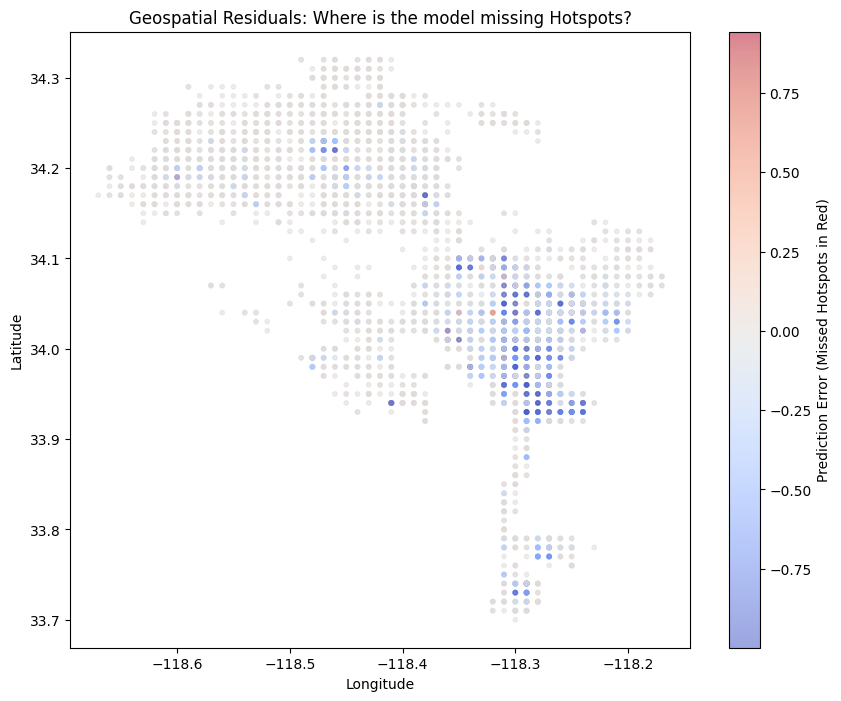

In [ ]:
# Grid Setup (~1km cells)
grid_size = 0.01 
df["lat_grid"] = (df["LAT"] // grid_size) * grid_size
df["lon_grid"] = (df["LON"] // grid_size) * grid_size

# Aggregate by Month
crime_grid = (
    df.groupby(["lat_grid", "lon_grid", df["DATE OCC"].dt.to_period('M')])
    .size()
    .reset_index(name="crime_count")
)
crime_grid.rename(columns={'DATE OCC': 'date'}, inplace=True)
crime_grid['date'] = crime_grid['date'].dt.to_timestamp()

# SPATIAL FILTER: Remove non-crime areas 
active_cells = crime_grid.groupby(['lat_grid', 'lon_grid'])['crime_count'].sum()
active_cells = active_cells[active_cells > 0].reset_index()[['lat_grid', 'lon_grid']]
crime_grid = crime_grid.merge(active_cells, on=['lat_grid', 'lon_grid'], how='inner')


# FEATURE ENGINEERING & CLASSIFICATION LABEL
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"])
grouped = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"]

# Spatiotemporal Features
crime_grid["lag_1"] = grouped.shift(1)
crime_grid["lag_3"] = grouped.shift(3)
crime_grid["rolling_mean_3"] = grouped.transform(lambda x: x.shift(1).rolling(3).mean())
crime_grid.dropna(inplace=True)

# THE HOTSPOT THRESHOLD
# Define a Hotspot as the top 10% of crime activity
threshold = crime_grid["crime_count"].quantile(0.90)
crime_grid["is_hotspot"] = (crime_grid["crime_count"] > threshold).astype(int)

# BALANCED TRAIN/TEST SPLIT
features = ["lat_grid", "lon_grid", "lag_1", "lag_3", "rolling_mean_3"]
train_raw = crime_grid[crime_grid["date"] < "2024-01-01"].copy()
test = crime_grid[crime_grid["date"] >= "2024-01-01"].copy()

# UNDERSAMPLING: Fix Imbalance for Training
hot_cells = train_raw[train_raw["is_hotspot"] == 1]
cold_cells = train_raw[train_raw["is_hotspot"] == 0]
# Sample cold cells to a 2:1 ratio (to keep the model sensitive to hotspots)
cold_sampled = cold_cells.sample(n=len(hot_cells) * 2, random_state=42)
train_balanced = pd.concat([hot_cells, cold_sampled])

X_train, y_train = train_balanced[features], train_balanced["is_hotspot"]
X_test, y_test_binary = test[features], test["is_hotspot"]
y_test_actual_counts = test["crime_count"] # Kept for Capture Rate calculation

# MODELING: CLASSIFIERS
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
rf_probs = rf_clf.predict_proba(X_test)[:, 1]

# XGBoost Classifier
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=6, 
    scale_pos_weight=2, # Weights 'Hotspots' more heavily
    random_state=42
)
xgb_clf.fit(X_train, y_train)
xgb_probs = xgb_clf.predict_proba(X_test)[:, 1]

# EVALUATION
def capture_rate(y_actual_counts, y_probs, top_percent=0.1):
    eval_df = pd.DataFrame({'actual_count': y_actual_counts, 'prob': y_probs})
    n_top = int(len(eval_df) * top_percent)
    top_indices = eval_df.sort_values('prob', ascending=False).head(n_top).index
    return eval_df.loc[top_indices, 'actual_count'].sum() / eval_df['actual_count'].sum()

def evaluate_classification(name, y_true, y_probs, y_actual_counts):
    # Binary predictions (standard 0.5 threshold)
    y_pred = (y_probs > 0.5).astype(int)
    
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    cap_10 = capture_rate(y_actual_counts, y_probs, 0.1)
    
    print(f"\n--- {name} HOTSPOT CLASSIFICATION ---")
    print(f"Precision (Accuracy of Hotspot Alarms): {prec:.4f}")
    print(f"Recall (How many Hotspots we caught): {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"Top 10% Capture Rate: {cap_10:.2%}")

evaluate_classification("Random Forest", y_test_binary, rf_probs, y_test_actual_counts)
evaluate_classification("XGBoost", y_test_binary, xgb_probs, y_test_actual_counts)

# GEOSPATIAL ERROR VISUALIZATION
test_results = X_test.copy()
test_results['actual'] = y_test_binary
test_results['pred_prob'] = xgb_probs
# Residuals in classification = Probabilistic distance from truth
test_results['error'] = test_results['actual'] - test_results['pred_prob']

plt.figure(figsize=(10, 8))
# Red = Actual Hotspot missed by model; Blue = Predicted Hotspot that wasn't one
plt.scatter(test_results['lon_grid'], test_results['lat_grid'], 
            c=test_results['error'], cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(label='Prediction Error (Missed Hotspots in Red)')
plt.title("Geospatial Residuals: Where is the model missing Hotspots?")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()